In [1]:
set.seed(405)
options(stringsAsFactors = FALSE)

In [2]:
required_packages <- c("rstan", "loo", "dplyr", "readr", "tibble", "ggplot2", "bayesplot", "tidyr")
missing_packages <- required_packages[!vapply(required_packages, requireNamespace, logical(1), quietly = TRUE)]
if (length(missing_packages) > 0) install.packages(missing_packages, repos = "https://cloud.r-project.org")
invisible(lapply(required_packages, library, character.only = TRUE))

Loading required package: StanHeaders


rstan version 2.32.7 (Stan version 2.32.2)


For execution on a local, multicore CPU with excess RAM we recommend calling
options(mc.cores = parallel::detectCores()).
To avoid recompilation of unchanged Stan programs, we recommend calling
rstan_options(auto_write = TRUE)
For within-chain threading using `reduce_sum()` or `map_rect()` Stan functions,
change `threads_per_chain` option:
rstan_options(threads_per_chain = 1)


Warning message:
“package ‘loo’ was built under R version 4.4.3”
This is loo version 2.9.0

- Online documentation and vignettes at mc-stan.org/loo

- As of v2.0.0 loo defaults to 1 core but we recommend using as many as possible. Use the 'cores' argument or set options(mc.cores = NUM_CORES) for an entire session. 


Attaching package: ‘loo’


The following object is masked from ‘package:rstan’:

    loo


Warning message:
“package ‘dplyr’ was built under R version 4.4.3”

Attaching package: ‘dplyr’


The following objects are m

In [3]:
if (!file.exists("../output/model1_nuts/fit_m1_nuts.rds")) stop("Missing Model 1 fit file. Run Notebook 4 first.")
if (!file.exists("../output/model2_nuts/fit_m2_nuts.rds")) stop("Missing Model 2 fit file. Run Notebook 5 first.")

fit_m1 <- readRDS("../output/model1_nuts/fit_m1_nuts.rds")
fit_m2 <- readRDS("../output/model2_nuts/fit_m2_nuts.rds")

In [4]:
model_tbl <- readr::read_csv("../output/derived/gss_2024_model_table.csv", show_col_types = FALSE) %>%
  dplyr::mutate(
    degree = as.factor(degree),
    sex = as.factor(sex),
    region = as.factor(region),
    polviews_bin = factor(polviews_bin, levels = c("Liberal", "Moderate", "Conservative"))
  )

m1_tbl <- model_tbl %>%
  dplyr::filter(!is.na(confinan_ord), !is.na(polviews), !is.na(age_std), !is.na(income_std), !is.na(degree), !is.na(sex), !is.na(region))
m2_tbl <- model_tbl %>%
  dplyr::filter(!is.na(confinan_ord), !is.na(polviews_bin), !is.na(age_std), !is.na(income_std), !is.na(degree), !is.na(sex), !is.na(region))

y_m1 <- as.integer(m1_tbl$confinan_ord)
y_m2 <- as.integer(m2_tbl$confinan_ord)
ideology_m2 <- m2_tbl$polviews_bin

In [5]:
log_lik_m1 <- rstan::extract(fit_m1, pars = "log_lik", permuted = TRUE)$log_lik
log_lik_m2 <- rstan::extract(fit_m2, pars = "log_lik", permuted = TRUE)$log_lik

if (is.null(log_lik_m1) || nrow(log_lik_m1) == 0) stop("Model 1 log_lik draws missing.")
if (is.null(log_lik_m2) || nrow(log_lik_m2) == 0) stop("Model 2 log_lik draws missing.")

loo_m1 <- loo::loo(log_lik_m1)
loo_m2 <- loo::loo(log_lik_m2)
loo_cmp <- loo::loo_compare(loo_m1, loo_m2)
loo_cmp

,elpd_diff,se_diff,elpd_loo,se_elpd_loo,p_loo,se_p_loo,looic,se_looic
model2,0.0000000,0.000000,-2136.731,24.10931,14.06129,0.3600920,4273.461,48.21862
model1,-0.1527058,1.478984,-2136.883,24.13051,12.94377,0.3386971,4273.767,48.26102


In [6]:
loo_summary <- tibble::tibble(
  model = c("Model1", "Model2"),
  elpd_loo = c(loo_m1$estimates["elpd_loo", "Estimate"], loo_m2$estimates["elpd_loo", "Estimate"]),
  se_elpd_loo = c(loo_m1$estimates["elpd_loo", "SE"], loo_m2$estimates["elpd_loo", "SE"]),
  p_loo = c(loo_m1$estimates["p_loo", "Estimate"], loo_m2$estimates["p_loo", "Estimate"]),
  looic = c(loo_m1$estimates["looic", "Estimate"], loo_m2$estimates["looic", "Estimate"])
) %>%
  dplyr::arrange(dplyr::desc(elpd_loo))

elpd_diff_m2_minus_m1 <- loo_m2$estimates["elpd_loo", "Estimate"] - loo_m1$estimates["elpd_loo", "Estimate"]
se_diff_approx <- sqrt(loo_m1$estimates["elpd_loo", "SE"]^2 + loo_m2$estimates["elpd_loo", "SE"]^2)

loo_diff <- tibble::tibble(metric = c("elpd_diff_m2_minus_m1", "se_diff_approx"), value = c(elpd_diff_m2_minus_m1, se_diff_approx))

loo_summary

model,elpd_loo,se_elpd_loo,p_loo,looic
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Model2,-2136.731,24.10931,14.06129,4273.461
Model1,-2136.883,24.13051,12.94377,4273.767


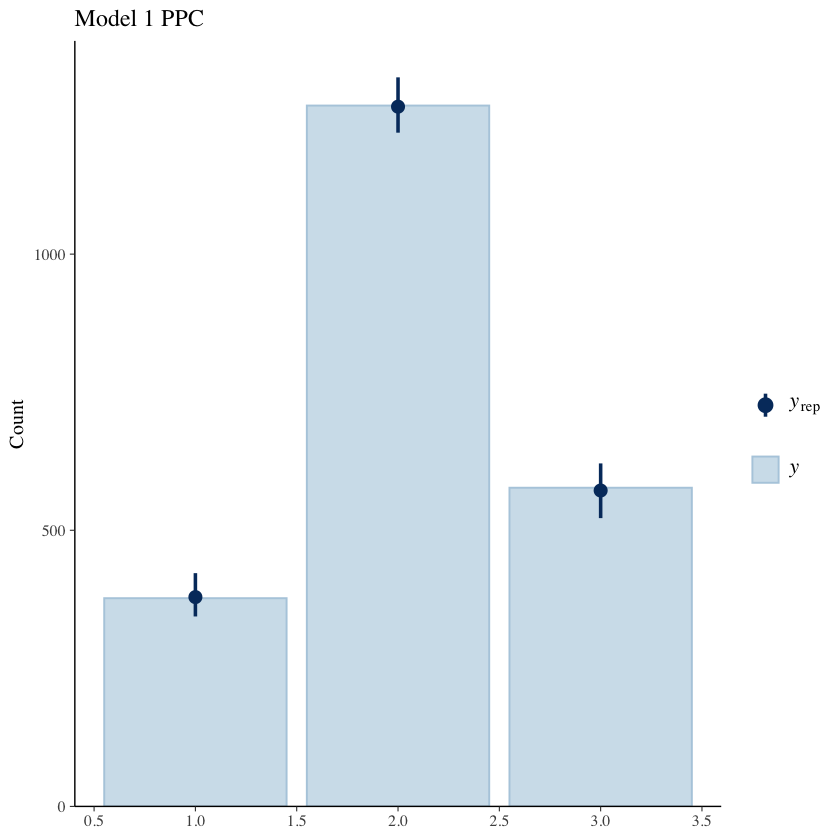

In [7]:
yrep_m1 <- rstan::extract(fit_m1, pars = "y_rep", permuted = TRUE)$y_rep
yrep_m2 <- rstan::extract(fit_m2, pars = "y_rep", permuted = TRUE)$y_rep

if (is.null(yrep_m1) || nrow(yrep_m1) == 0) stop("Model 1 y_rep missing.")
if (is.null(yrep_m2) || nrow(yrep_m2) == 0) stop("Model 2 y_rep missing.")

yrep_m1_subset <- yrep_m1[sample.int(nrow(yrep_m1), min(200, nrow(yrep_m1))), , drop = FALSE]
yrep_m2_subset <- yrep_m2[sample.int(nrow(yrep_m2), min(200, nrow(yrep_m2))), , drop = FALSE]

ppc_m1 <- bayesplot::ppc_bars(y = y_m1, yrep = yrep_m1_subset) + ggplot2::ggtitle("Model 1 PPC")
ppc_m2 <- bayesplot::ppc_bars(y = y_m2, yrep = yrep_m2_subset) + ggplot2::ggtitle("Model 2 PPC")

ppc_m1

In [8]:
category_props <- function(y_vec) {
  tab <- table(factor(y_vec, levels = c(1, 2, 3)))
  as.numeric(tab) / sum(tab)
}

obs_prop_m1 <- category_props(y_m1)
obs_prop_m2 <- category_props(y_m2)

pred_prop_m1 <- t(apply(yrep_m1, 1, category_props))
pred_prop_m2 <- t(apply(yrep_m2, 1, category_props))

ppc_table_m1 <- tibble::tibble(
  category = c(1, 2, 3),
  observed = obs_prop_m1,
  pred_mean = apply(pred_prop_m1, 2, mean),
  pred_q025 = apply(pred_prop_m1, 2, stats::quantile, probs = 0.025),
  pred_q975 = apply(pred_prop_m1, 2, stats::quantile, probs = 0.975)
) %>%
  dplyr::mutate(model = "Model1")

ppc_table_m2 <- tibble::tibble(
  category = c(1, 2, 3),
  observed = obs_prop_m2,
  pred_mean = apply(pred_prop_m2, 2, mean),
  pred_q025 = apply(pred_prop_m2, 2, stats::quantile, probs = 0.025),
  pred_q975 = apply(pred_prop_m2, 2, stats::quantile, probs = 0.975)
) %>%
  dplyr::mutate(model = "Model2")

ppc_category_table <- dplyr::bind_rows(ppc_table_m1, ppc_table_m2)
ppc_category_table

category,observed,pred_mean,pred_q025,pred_q975,model
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,0.1695906,0.1696652,0.1479982,0.1920828,Model1
2,0.5708502,0.5699489,0.5416104,0.5982906,Model1
3,0.2595592,0.2603859,0.2352677,0.2860999,Model1
1,0.1695906,0.1695024,0.1484480,0.1911831,Model2
2,0.5708502,0.5700910,0.5407108,0.5982906,Model2
3,0.2595592,0.2604067,0.2361673,0.2860999,Model2


In [9]:
ideology_levels <- levels(ideology_m2)

ppc_by_ideology <- dplyr::bind_rows(lapply(ideology_levels, function(g) {
  idx <- which(ideology_m2 == g)
  obs <- category_props(y_m2[idx])
  pred_sub <- yrep_m2[, idx, drop = FALSE]
  pred_props <- t(apply(pred_sub, 1, category_props))
  tibble::tibble(
    ideology = g,
    category = c(1, 2, 3),
    observed = obs,
    pred_mean = apply(pred_props, 2, mean),
    pred_q025 = apply(pred_props, 2, stats::quantile, probs = 0.025),
    pred_q975 = apply(pred_props, 2, stats::quantile, probs = 0.975)
  )
}))

ppc_by_ideology

ideology,category,observed,pred_mean,pred_q025,pred_q975
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Liberal,1,0.1576011,0.1625331,0.1296722,0.1980474
Liberal,2,0.5676430,0.5670631,0.5244073,0.6094840
Liberal,3,0.2747559,0.2704038,0.2287308,0.3152022
Moderate,1,0.1834975,0.1722574,0.1391626,0.2068966
Moderate,2,0.5615764,0.5715062,0.5332512,0.6108374
Moderate,3,0.2549261,0.2562365,0.2167488,0.2967980
Conservative,1,0.1657061,0.1734791,0.1383285,0.2103746
Conservative,2,0.5850144,0.5715634,0.5273775,0.6138329
Conservative,3,0.2492795,0.2549575,0.2146974,0.2982709


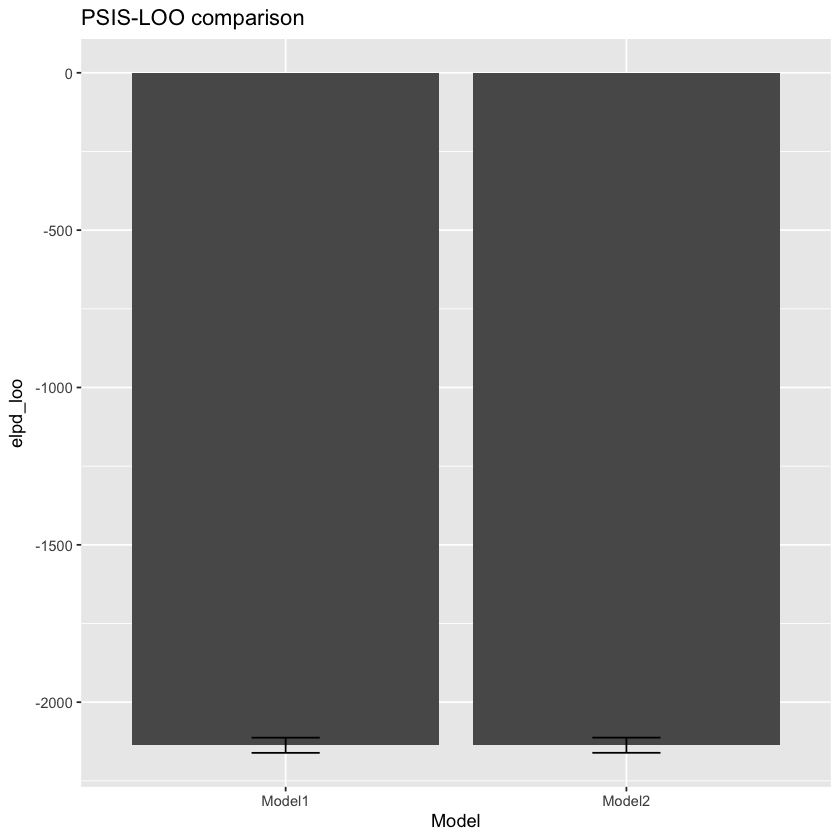

In [10]:
p_loo <- ggplot2::ggplot(loo_summary, ggplot2::aes(x = model, y = elpd_loo)) +
  ggplot2::geom_col() +
  ggplot2::geom_errorbar(ggplot2::aes(ymin = elpd_loo - se_elpd_loo, ymax = elpd_loo + se_elpd_loo), width = 0.2) +
  ggplot2::labs(x = "Model", y = "elpd_loo", title = "PSIS-LOO comparison")

p_ppc_cat <- ggplot2::ggplot(ppc_category_table, ggplot2::aes(x = factor(category), y = observed, color = model, group = model)) +
  ggplot2::geom_point(position = ggplot2::position_dodge(width = 0.25), size = 2) +
  ggplot2::geom_point(ggplot2::aes(y = pred_mean), position = ggplot2::position_dodge(width = 0.25), shape = 1, size = 2) +
  ggplot2::labs(x = "Outcome category", y = "Proportion", title = "Observed vs predicted category proportions")

p_ppc_ideo <- ggplot2::ggplot(ppc_by_ideology, ggplot2::aes(x = factor(category), y = observed)) +
  ggplot2::geom_point(size = 2) +
  ggplot2::geom_point(ggplot2::aes(y = pred_mean), shape = 1, size = 2) +
  ggplot2::facet_wrap(~ ideology) +
  ggplot2::labs(x = "Outcome category", y = "Proportion", title = "Model 2 PPC by ideology")

p_loo

In [11]:
dir.create("../output/model_compare", recursive = TRUE, showWarnings = FALSE)
readr::write_csv(loo_summary, "../output/model_compare/loo_summary.csv")
readr::write_csv(loo_diff, "../output/model_compare/loo_diff.csv")
readr::write_csv(ppc_category_table, "../output/model_compare/ppc_category_table.csv")
readr::write_csv(ppc_by_ideology, "../output/model_compare/ppc_by_ideology.csv")
ggplot2::ggsave(filename = "../output/model_compare/loo_comparison.png", plot = p_loo, width = 6.5, height = 4.5, dpi = 150)
ggplot2::ggsave(filename = "../output/model_compare/ppc_model1_bars.png", plot = ppc_m1, width = 6.5, height = 4.5, dpi = 150)
ggplot2::ggsave(filename = "../output/model_compare/ppc_model2_bars.png", plot = ppc_m2, width = 6.5, height = 4.5, dpi = 150)
ggplot2::ggsave(filename = "../output/model_compare/ppc_category_compare.png", plot = p_ppc_cat, width = 7, height = 4.5, dpi = 150)
ggplot2::ggsave(filename = "../output/model_compare/ppc_model2_by_ideology.png", plot = p_ppc_ideo, width = 8, height = 4.5, dpi = 150)